In [69]:
from keras.datasets import mnist
from keras.utils import to_categorical
from keras import models , layers
import matplotlib.pyplot as plt
import numpy as np

In [70]:
(train_x,train_y) , (test_x,test_y) = mnist.load_data()

In [71]:
print(f"train_x.shape : {train_x.shape}")
print(f"train_y.shape : {train_y.shape}")
print(f"test_x.shape : {test_x.shape}")
print(f"test_y.shape : {test_y.shape}")

train_x.shape : (60000, 28, 28)
train_y.shape : (60000,)
test_x.shape : (10000, 28, 28)
test_y.shape : (10000,)


In [72]:
train_x = train_x.reshape(train_x.shape[0],28*28).astype('float32') / 255
test_x = test_x.reshape(test_x.shape[0],28*28).astype('float32') / 255

test_y = to_categorical(test_y)
train_y = to_categorical(train_y)

In [73]:
val_x = train_x[50000:]
val_y = train_y[50000:]

train_x = train_x[:50000]
train_y = train_y[:50000]

In [74]:
classNum = train_y.shape[1]

model = models.Sequential([
    layers.Dense(96,activation='relu',input_shape=(28*28,)),
    layers.Dense(64,activation='relu'),
    layers.Dense(classNum , activation='softmax')
])

model.compile(optimizer='rmsprop',loss='categorical_crossentropy',metrics=['accuracy'])

/Users/ponlawatchangto/Desktop/VsCode/Mylearning/4312/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [75]:
history = model.fit(train_x,train_y,epochs=30,batch_size=1024,validation_data=(val_x,val_y))

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8013 - loss: 0.7820 - val_accuracy: 0.8954 - val_loss: 0.3681
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9068 - loss: 0.3262 - val_accuracy: 0.9243 - val_loss: 0.2712
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9267 - loss: 0.2551 - val_accuracy: 0.9394 - val_loss: 0.2142
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9370 - loss: 0.2154 - val_accuracy: 0.9482 - val_loss: 0.1855
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9458 - loss: 0.1877 - val_accuracy: 0.9499 - val_loss: 0.1731
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9522 - loss: 0.1658 - val_accuracy: 0.9578 - val_loss: 0.1569
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9567 - loss: 0.1487 - val_accuracy: 0.9611 - val_loss: 0.1423
Epoch 8/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9606 - loss: 0.1344 - val_accuracy: 0.9607 - val_loss:

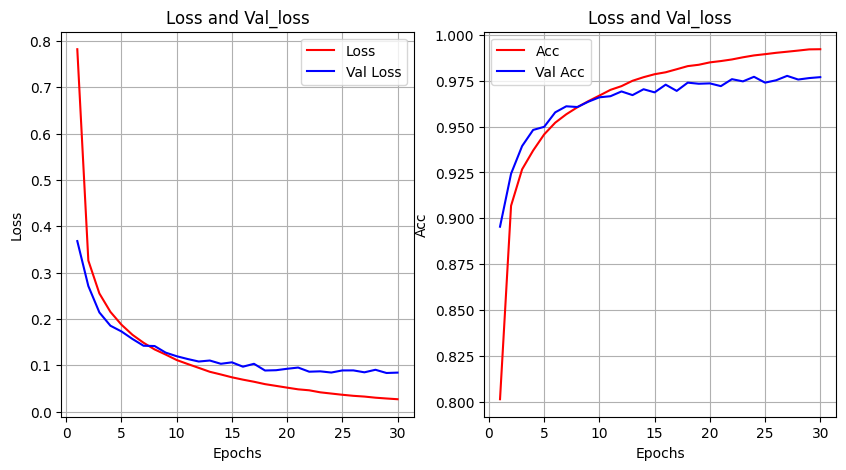

In [76]:
loss = history.history['loss']
acc = history.history['accuracy']
val_loss = history.history['val_loss']
val_acc = history.history['val_accuracy']
epochs = range(1,len(loss)+1)

size=5
plt.figure(figsize=(size*2,size))

plt.subplot(1,2,1)
plt.title('Loss and Val_loss')
plt.grid(True)
plt.plot(epochs,loss,'r',label='Loss')
plt.plot(epochs,val_loss,'b',label='Val Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.subplot(1,2,2)
plt.title('Loss and Val_loss')
plt.grid(True)
plt.plot(epochs,acc,'r',label='Acc')
plt.plot(epochs,val_acc,'b',label='Val Acc')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Acc')

plt.show()

In [79]:
loss , acc = history.model.evaluate(test_x,test_y)
print(loss)
print(acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 324us/step - accuracy: 0.9765 - loss: 0.0754
0.07539651542901993
0.9764999747276306


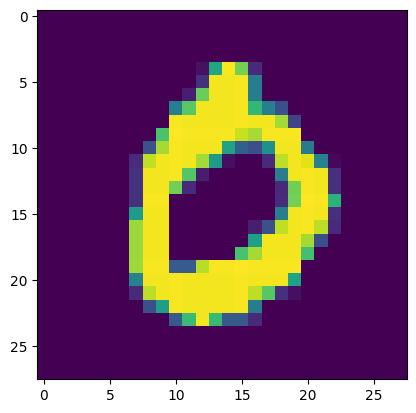

Predicted digit: 0


In [90]:
index = 3
plt.imshow(test_x[index].reshape(28, 28))
plt.show()

sample = np.expand_dims(test_x[index], axis=0)  # หรือ test_x[index:index+1]
prediction = model.predict(sample, verbose=0)
predicted_digit = np.argmax(prediction[0])      # MNIST คือเลข 0-9
print(f"Predicted digit: {predicted_digit}")